# Rekomendasi Skincare Terintegrasi CNN

### Mapping CNN Level → Skincare
| CNN Level | Kondisi Kulit | Fokus Skincare |
|-----------|--------------|----------------|
| **Level 0** | Sangat ringan / sehat | Maintenance, hidrasi, anti-aging |
| **Level 1** | Ringan | Jerawat ringan, pori besar, flek |
| **Level 2** | Sedang | Jerawat sedang, bekas jerawat, iritasi |
| **Level 3** | Berat | Jerawat parah, iritasi berat → intensif + dokter |

---
### Alur Pipeline
1. Import & Konfigurasi
2. Load Dataset Skincare
3. Preprocessing & TF-IDF
4. Mapping CNN Level → Profil Skincare
5. Fungsi Rekomendasi Terintegrasi
6. Demo: Input Level CNN → Output Rekomendasi
7. Demo: Input Gambar Langsung (pakai CNN)
8. Simpan Model

---
## 1. Import & Konfigurasi

In [114]:
import os, io, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_columns', None)

# ── Konfigurasi ──────────────────────────────────────────────
CONFIG = {
    # Path file
    'csv_path'          : '../dataset/dataset_skincare_ready.csv', 
    'cnn_model_path'    : '../output/best_model.keras',
    'output_model_path' : '../output/skincare_cnn_integrated.pkl',

    # Rekomendasi
    'top_n'             : 5,
    'img_size'          : (224, 224),

    # Bobot scoring (total = 1.0)
    'weight_cosine'     : 0.30,
    'weight_skor'       : 0.30,
    'weight_level'      : 0.25,   # bobot lebih besar karena level dari CNN
    'weight_kulit'      : 0.15,

    'seed'              : 42,
}

COLORS = ['#4C72B0','#55A868','#DD8452','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C']
CNN_CLASS_NAMES = ['Level 0', 'Level 1', 'Level 2', 'Level 3']

print('✅ Import selesai')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')

✅ Import selesai
   Pandas  : 2.3.3
   NumPy   : 1.26.4


---
## 2. Load Dataset Skincare

In [115]:
if os.path.exists(CONFIG['csv_path']):
    df = pd.read_csv(CONFIG['csv_path'])
    print(f'✅ Dataset dimuat: {CONFIG["csv_path"]}')
else:
    # Data bawaan (subset dari dataset asli)
    print('⚠️dataset CSV tidak ditemukan')


# Normalisasi teks
str_cols = ['Brand','Produk','Jenis_Produk_Final','Tipe_Bahan_Aktif_Final',
            'Masalah Kulit','Untuk Kulit','ingredient_name','function1',
            'function2','warning1','warning2','Label_Level']
for c in str_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()
    else:
        df[c] = ''

if 'Level_Utama' in df.columns:
    df['Level_Utama'] = pd.to_numeric(df['Level_Utama'], errors='coerce').fillna(-1).astype(int)
else:
    raise KeyError('Kolom Level_Utama tidak ditemukan di dataset')

if 'Skor_Rekomendasi' in df.columns:
    df['Skor_Rekomendasi'] = pd.to_numeric(df['Skor_Rekomendasi'], errors='coerce').fillna(0.0)
else:
    raise KeyError('Kolom Skor_Rekomendasi tidak ditemukan di dataset')

print(f'Shape  : {df.shape}')
print(f'\nLevel_Utama unik : {sorted(df["Level_Utama"].unique())}')
print(f'Label_Level unik  : {sorted(df["Label_Level"].unique())[:10]}')
print(f'Masalah unik     : {sorted(df["Masalah Kulit"].unique())}')
print(f'Kulit unik       : {sorted(df["Untuk Kulit"].unique())}')
df.head(3)

✅ Dataset dimuat: ../dataset/dataset_skincare_ready.csv
Shape  : (185, 15)

Level_Utama unik : [0, 1, 2, 3]
Label_Level unik  : ['Tingkat 0 — Kulit normal atau sangat ringan', 'Tingkat 1 — Jerawat ringan', 'Tingkat 2 — Jerawat sedang', 'Tingkat 3 — Jerawat berat']
Masalah unik     : ['Bekas jerawat', 'Dehidrasi', 'Flek hitam', 'Iritasi', 'Jerawat', 'Kusam', 'Penuaan', 'Pori besar']
Kulit unik       : ['Berminyak', 'Kering', 'Kombinasi', 'Normal', 'Sensitif']


,Brand,Produk,Jenis_Produk_Final,Tipe_Bahan_Aktif_Final,Masalah Kulit,Untuk Kulit,ingredient_name,function1,function2,warning1,warning2,Level_Utama,Label_Level,Skor_Rekomendasi,Catatan_Rekomendasi
0,Avoskin,Tea Tree Spot Gel,Spot Treatment,Tea Tree,Jerawat,Berminyak,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,1,Tingkat 1 — Jerawat ringan,3,Produk cocok untuk perawatan jerawat ringan karena mendu...
1,Dear Me Beauty,Bakuchiol Night Cream,Night Cream,Bakuchiol,Dehidrasi,Kering,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,Tidak ditemukan di data referensi,3,Tingkat 3 — Jerawat berat,0,Produk dapat membantu mendukung perawatan jerawat berat ...
2,Somethinc,Glow Boost Serum,Serum,Salicylic Acid,Flek hitam,Berminyak,Salicylic Acid,Exfoliant,Tidak Ada,Exfoliating,Irritant,1,Tingkat 1 — Jerawat ringan,2,Produk cocok untuk perawatan jerawat ringan karena mendu...


---
## 3. Preprocessing & TF-IDF

In [116]:
# Normalisasi skor
scaler = MinMaxScaler()
df['skor_norm'] = scaler.fit_transform(df[['Skor_Rekomendasi']])

# Feature text gabungan untuk TF-IDF
df['text_features'] = (
    df['Masalah Kulit'].fillna('')          + ' ' +
    df['Untuk Kulit'].fillna('')            + ' ' +
    df['Tipe_Bahan_Aktif_Final'].fillna('') + ' ' +
    df['Jenis_Produk_Final'].fillna('')     + ' ' +
    df['ingredient_name'].fillna('')        + ' ' +
    df['function1'].fillna('')              + ' ' +
    df['function2'].fillna('')              + ' ' +
    df['Label_Level'].fillna('')
).str.lower()

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, max_features=500)
tfidf_matrix = tfidf.fit_transform(df['text_features'])

print(f'✅ Preprocessing selesai')
print(f'   TF-IDF matrix : {tfidf_matrix.shape}')

✅ Preprocessing selesai
   TF-IDF matrix : (185, 242)


---
## 4. Mapping CNN Level → Profil Skincare

Ini adalah **inti integrasi**: setiap output CNN level 0-3 dipetakan ke profil skincare yang relevan.

In [117]:
# ═══════════════════════════════════════════════════════════
# MAPPING CNN LEVEL → PROFIL SKINCARE
# Sesuaikan sesuai domain knowledge Anda
# ═══════════════════════════════════════════════════════════
CNN_TO_SKINCARE_PROFILE = {
    0: {
        'label'             : 'Level 0 — Kulit Normal atau Sangat Ringan',
        'deskripsi'         : 'Kulit normal atau sangat ringan. Fokus pada maintenance, hidrasi, dan pencegahan.',
        'skincare_levels'   : [0],   # Level_Utama yang dicari di dataset
        'masalah_default'   : ['Dehidrasi', 'Kusam', 'Penuaan'],
        'bahan_rekomendasi' : ['Hyaluronic Acid', 'Ceramide', 'Bakuchiol'],
        'warna'             : '#55A868',
        'emoji'             : '🟢',
        'saran_dokter'      : False,
    },
    1: {
        'label'             : 'Level 1 — Jerawat Ringan',
        'deskripsi'         : 'Jerawat ringan. Perlu skincare rutin dengan bahan aktif ringan.',
        'skincare_levels'   : [1],
        'masalah_default'   : ['Jerawat', 'Pori besar', 'Flek hitam'],
        'bahan_rekomendasi' : ['Niacinamide', 'Tea Tree', 'Salicylic Acid'],
        'warna'             : '#4C72B0',
        'emoji'             : '🔵',
        'saran_dokter'      : False,
    },
    2: {
        'label'             : 'Level 2 — Jerawat Sedang',
        'deskripsi'         : 'Masalah kulit sedang. Butuh bahan aktif yang lebih targeted dan konsisten.',
        'skincare_levels'   : [2],
        'masalah_default'   : ['Jerawat', 'Bekas jerawat', 'Iritasi'],
        'bahan_rekomendasi' : ['Niacinamide', 'Ceramide', 'Tea Tree', 'Salicylic Acid'],
        'warna'             : '#DD8452',
        'emoji'             : '🟠',
        'saran_dokter'      : False,
    },
    3: {
        'label'             : 'Level 3 — Jerawat Berat',
        'deskripsi'         : 'Masalah kulit berat. Perlu skincare intensif. Disarankan konsultasi dokter kulit.',
        'skincare_levels'   : [3],
        'masalah_default'   : ['Jerawat', 'Iritasi', 'Bekas jerawat'],
        'bahan_rekomendasi' : ['Ceramide', 'Niacinamide'],
        'warna'             : '#C44E52',
        'emoji'             : '🔴',
        'saran_dokter'      : True,
    },
}

# Tampilkan mapping
print('═'*65)
print('  MAPPING CNN LEVEL → PROFIL SKINCARE')
print('═'*65)
for lvl, info in CNN_TO_SKINCARE_PROFILE.items():
    print(f"\n{info['emoji']} CNN {info['label']}")
    print(f"   Deskripsi    : {info['deskripsi']}")
    print(f"   Level Filter : {info['skincare_levels']}")
    print(f"   Masalah      : {info['masalah_default']}")
    print(f"   Bahan        : {info['bahan_rekomendasi']}")
    print(f"   Saran Dokter : {'⚠️  Ya' if info['saran_dokter'] else 'Tidak'}")

═════════════════════════════════════════════════════════════════
  MAPPING CNN LEVEL → PROFIL SKINCARE
═════════════════════════════════════════════════════════════════

🟢 CNN Level 0 — Kulit Normal atau Sangat Ringan
   Deskripsi    : Kulit normal atau sangat ringan. Fokus pada maintenance, hidrasi, dan pencegahan.
   Level Filter : [0]
   Masalah      : ['Dehidrasi', 'Kusam', 'Penuaan']
   Bahan        : ['Hyaluronic Acid', 'Ceramide', 'Bakuchiol']
   Saran Dokter : Tidak

🔵 CNN Level 1 — Jerawat Ringan
   Deskripsi    : Jerawat ringan. Perlu skincare rutin dengan bahan aktif ringan.
   Level Filter : [1]
   Masalah      : ['Jerawat', 'Pori besar', 'Flek hitam']
   Bahan        : ['Niacinamide', 'Tea Tree', 'Salicylic Acid']
   Saran Dokter : Tidak

🟠 CNN Level 2 — Jerawat Sedang
   Deskripsi    : Masalah kulit sedang. Butuh bahan aktif yang lebih targeted dan konsisten.
   Level Filter : [2]
   Masalah      : ['Jerawat', 'Bekas jerawat', 'Iritasi']
   Bahan        : ['Niacinamide',

---
## 5. Fungsi Rekomendasi Terintegrasi

In [118]:
def recommend_from_cnn_level(
    cnn_level       : int,
    jenis_kulit     : str,
    masalah_kulit   : str  = None,   # None = pakai default dari mapping
    bahan_preferred : str  = None,   # None = pakai default dari mapping
    jenis_produk    : str  = None,   # filter opsional
    top_n           : int  = None,
    exclude_warning : bool = False,
) -> dict:

    if cnn_level not in CNN_TO_SKINCARE_PROFILE:
        raise ValueError(f'cnn_level harus 0-3, diterima: {cnn_level}')

    top_n   = top_n or CONFIG['top_n']
    profile = CNN_TO_SKINCARE_PROFILE[cnn_level]

    # Gunakan masalah & bahan dari mapping jika tidak diisi user
    masalah_list  = [masalah_kulit] if masalah_kulit else profile['masalah_default']
    bahan_list    = [bahan_preferred] if bahan_preferred else profile['bahan_rekomendasi']
    target_levels = profile['skincare_levels']

    # ── Filter dataset berdasarkan Level_Utama ────────────────
    df_filtered = df[df['Level_Utama'].isin(target_levels)].copy()

    # Jika hasil filter terlalu sedikit, gunakan semua data
    if len(df_filtered) < top_n:
        df_filtered = df.copy()

    # ── TF-IDF query ──────────────────────────────────────────
    query_parts = masalah_list + [jenis_kulit] + bahan_list
    if jenis_produk:
        query_parts.append(jenis_produk)
    query_text = ' '.join(query_parts).lower()
    query_vec  = tfidf.transform([query_text])

    # Hitung cosine similarity hanya untuk baris yang difilter
    filtered_idx = df_filtered.index
    cos_sim_all  = cosine_similarity(query_vec, tfidf_matrix).flatten()
    cos_sim      = cos_sim_all[filtered_idx]

    # ── Rule-based score ──────────────────────────────────────
    mask_masalah = df_filtered['Masalah Kulit'].isin(masalah_list).astype(float)
    mask_kulit   = (df_filtered['Untuk Kulit'].str.lower() == jenis_kulit.lower()).astype(float)
    mask_bahan   = df_filtered['Tipe_Bahan_Aktif_Final'].isin(bahan_list).astype(float) * 0.3
    mask_level   = df_filtered['Level_Utama'].isin(target_levels).astype(float)
    bonus_produk = (df_filtered['Jenis_Produk_Final'].str.lower() == (jenis_produk or '').lower()).astype(float) * 0.2 if jenis_produk else 0

    rule_score  = np.clip(
        mask_masalah * 0.4 + mask_kulit * 0.3 + mask_bahan + bonus_produk, 0, 1
    )

    # ── Final weighted score ──────────────────────────────────
    final_score = (
        CONFIG['weight_cosine'] * cos_sim              +
        CONFIG['weight_skor']   * df_filtered['skor_norm'].values +
        CONFIG['weight_level']  * mask_level.values    +
        CONFIG['weight_kulit']  * rule_score.values
    )

    result = df_filtered.copy()
    result['cosine_sim']  = cos_sim
    result['rule_score']  = rule_score.values
    result['final_score'] = final_score

    # ── Filter opsional ───────────────────────────────────────
    if exclude_warning:
        result = result[result['warning1'].str.contains('Tidak ada|Aman', case=False, na=True)]
    if jenis_produk:
        f2 = result[result['Jenis_Produk_Final'].str.lower() == jenis_produk.lower()]
        if len(f2) >= top_n:
            result = f2

    result = (
        result
        .sort_values('final_score', ascending=False)
        .drop_duplicates(subset=['Brand','Produk'])
        .head(top_n)
        .reset_index(drop=True)
    )
    result.index += 1

    return {
        'cnn_level'       : cnn_level,
        'profile'         : profile,
        'masalah_dipakai' : masalah_list,
        'bahan_dipakai'   : bahan_list,
        'jenis_kulit'     : jenis_kulit,
        'rekomendasi'     : result,
    }

print('✅ Fungsi recommend_from_cnn_level() siap')

✅ Fungsi recommend_from_cnn_level() siap


---
## 6. Demo: Input Level CNN → Output Rekomendasi

In [119]:
# ════════════════════════════════════════════════════
#  🔧 UBAH PARAMETER INI SESUAI KEBUTUHAN
# ════════════════════════════════════════════════════
INPUT_CNN_LEVEL   = 2          # 0 / 1 / 2 / 3  ← output dari model CNN
INPUT_JENIS_KULIT = 'Berminyak' # Berminyak / Kering / Normal / Kombinasi / Sensitif
INPUT_MASALAH     = None        # None = otomatis dari mapping, atau isi: 'Jerawat', dll
INPUT_BAHAN       = None        # None = otomatis, atau: 'Niacinamide', 'Ceramide', dll
INPUT_JENIS_PRODUK= None        # None atau: 'Serum', 'Toner', 'Cleanser', dll
EXCLUDE_WARNING   = False
TOP_N             = 5
# ════════════════════════════════════════════════════

hasil = recommend_from_cnn_level(
    cnn_level       = INPUT_CNN_LEVEL,
    jenis_kulit     = INPUT_JENIS_KULIT,
    masalah_kulit   = INPUT_MASALAH,
    bahan_preferred = INPUT_BAHAN,
    jenis_produk    = INPUT_JENIS_PRODUK,
    top_n           = TOP_N,
    exclude_warning = EXCLUDE_WARNING,
)

p = hasil['profile']
print('═'*62)
print(f"  {p['emoji']} HASIL ANALISIS CNN")
print('═'*62)
print(f"  CNN Level      : {hasil['cnn_level']} — {p['label']}")
print(f"  Kondisi Kulit  : {p['deskripsi']}")
print(f"  Jenis Kulit    : {hasil['jenis_kulit']}")
print(f"  Masalah Focus  : {hasil['masalah_dipakai']}")
print(f"  Bahan Aktif    : {hasil['bahan_dipakai']}")
if p['saran_dokter']:
    print(f"  ⚠️  PERHATIAN   : Kondisi berat — disarankan konsultasi dokter kulit")
print('═'*62)

print(f'\n📋 TOP {TOP_N} REKOMENDASI PRODUK SKINCARE:')
display(
    hasil['rekomendasi'][['Brand','Produk','Jenis_Produk_Final',
                          'Tipe_Bahan_Aktif_Final','Untuk Kulit',
                          'Level_Utama','Skor_Rekomendasi','final_score']]
    .style
    .background_gradient(subset=['final_score'], cmap='Greens')
    .format({'final_score': '{:.3f}'})
)

══════════════════════════════════════════════════════════════
  🟠 HASIL ANALISIS CNN
══════════════════════════════════════════════════════════════
  CNN Level      : 2 — Level 2 — Jerawat Sedang
  Kondisi Kulit  : Masalah kulit sedang. Butuh bahan aktif yang lebih targeted dan konsisten.
  Jenis Kulit    : Berminyak
  Masalah Focus  : ['Jerawat', 'Bekas jerawat', 'Iritasi']
  Bahan Aktif    : ['Niacinamide', 'Ceramide', 'Tea Tree', 'Salicylic Acid']
══════════════════════════════════════════════════════════════

📋 TOP 5 REKOMENDASI PRODUK SKINCARE:


,Brand,Produk,Jenis_Produk_Final,Tipe_Bahan_Aktif_Final,Untuk Kulit,Level_Utama,Skor_Rekomendasi,final_score
1,The Ordinary,Miraculous Retinol Ampoule,Serum,Retinol,Berminyak,2,2,0.573
2,Wardah,Miraculous Retinol Ampoule,Serum,Retinol,Sensitif,2,2,0.481
3,Emina,Advanced Snail 96 Mucin Essence,Essence,Retinol,Kering,2,2,0.480
4,Scarlett,Hydrating Aloe Vera Gel,Gel Moisturizer,Retinol,Normal,2,2,0.478
5,Avoskin,Miraculous Retinol Ampoule,Serum,Retinol,Berminyak,2,2,0.463


In [120]:
# Detail lengkap setiap produk
print('\n DETAIL PRODUK REKOMENDASI:')
print('─'*62)
for i, row in hasil['rekomendasi'].iterrows():
    print(f'\n#{i} {row["Brand"]} — {row["Produk"]}')
    print(f'   Jenis      : {row["Jenis_Produk_Final"]}')
    print(f'   Bahan      : {row["Tipe_Bahan_Aktif_Final"]}')
    print(f'   Masalah    : {row["Masalah Kulit"]}')
    print(f'   Kulit      : {row["Untuk Kulit"]}')
    print(f'   Level      : {row["Level_Utama"]}')
    print(f'   Peringatan : {row["warning1"]}')
    print(f'   Skor       : {row["final_score"]:.4f}')
    print(f'   Catatan    : {str(row["Catatan_Rekomendasi"])[:80]}...')


 DETAIL PRODUK REKOMENDASI:
──────────────────────────────────────────────────────────────

#1 The Ordinary — Miraculous Retinol Ampoule
   Jenis      : Serum
   Bahan      : Retinol
   Masalah    : Iritasi
   Kulit      : Berminyak
   Level      : 2
   Peringatan : Irritant
   Skor       : 0.5730
   Catatan    : Produk dapat dipertimbangkan untuk jerawat sedang karena memiliki kandungan atau...

#2 Wardah — Miraculous Retinol Ampoule
   Jenis      : Serum
   Bahan      : Retinol
   Masalah    : Iritasi
   Kulit      : Sensitif
   Level      : 2
   Peringatan : Irritant
   Skor       : 0.4815
   Catatan    : Produk dapat dipertimbangkan untuk jerawat sedang karena memiliki kandungan atau...

#3 Emina — Advanced Snail 96 Mucin Essence
   Jenis      : Essence
   Bahan      : Retinol
   Masalah    : Iritasi
   Kulit      : Kering
   Level      : 2
   Peringatan : Irritant
   Skor       : 0.4795
   Catatan    : Produk dapat dipertimbangkan untuk jerawat sedang karena memiliki kandungan at

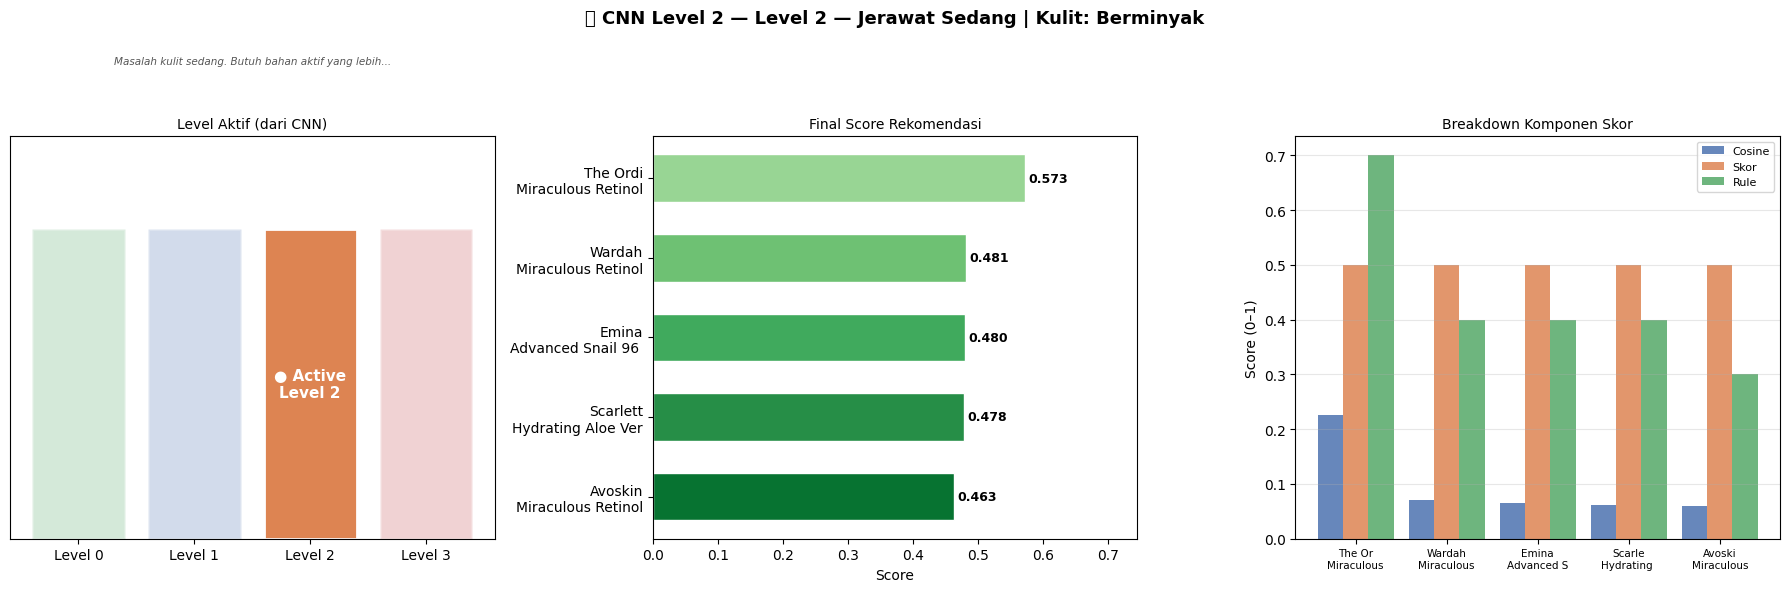

✅ Saved: rekomendasi_level2.png


In [121]:
# ── Visualisasi hasil ─────────────────────────────────────────
def visualize_result(hasil_dict):
    p    = hasil_dict['profile']
    rekom = hasil_dict['rekomendasi']
    lvl  = hasil_dict['cnn_level']

    fig = plt.figure(figsize=(18, 6))
    fig.suptitle(
        f"{p['emoji']} CNN Level {lvl} — {p['label']} | Kulit: {hasil_dict['jenis_kulit']}",
        fontsize=13, fontweight='bold'
    )

    # ── Panel kiri: level indicator ──
    ax0 = fig.add_subplot(1, 3, 1)
    level_colors = [CNN_TO_SKINCARE_PROFILE[i]['warna'] for i in range(4)]
    level_labels = [f"Level {i}" for i in range(4)]
    alphas = [1.0 if i == lvl else 0.25 for i in range(4)]
    bars = ax0.bar(level_labels, [1,1,1,1], color=level_colors, alpha=1.0, edgecolor='white', linewidth=2)
    for bar, a, i in zip(bars, alphas, range(4)):
        bar.set_alpha(a)
        if i == lvl:
            ax0.text(bar.get_x() + bar.get_width()/2, 0.5,
                     f'● Active\nLevel {i}', ha='center', va='center',
                     fontsize=11, fontweight='bold', color='white')
    ax0.set_ylim([0, 1.3])
    ax0.set_yticks([])
    ax0.set_title('Level Aktif (dari CNN)', fontsize=10)
    ax0.text(0.5, 1.18, p['deskripsi'][:50]+'...', transform=ax0.transAxes,
             ha='center', fontsize=7.5, style='italic', color='#555')

    # ── Panel tengah: bar final score ──
    ax1 = fig.add_subplot(1, 3, 2)
    labels = [f"{r['Brand'][:8]}\n{r['Produk'][:18]}" for _, r in rekom.iterrows()]
    scores = rekom['final_score'].values
    bar_c  = plt.cm.Greens(np.linspace(0.4, 0.85, len(scores)))
    bars2  = ax1.barh(labels[::-1], scores[::-1], color=bar_c[::-1], edgecolor='white', height=0.6)
    ax1.set_title('Final Score Rekomendasi', fontsize=10)
    ax1.set_xlabel('Score')
    ax1.set_xlim([0, max(scores)*1.3])
    for bar, v in zip(bars2, scores[::-1]):
        ax1.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    # ── Panel kanan: breakdown komponen ──
    ax2 = fig.add_subplot(1, 3, 3)
    x = np.arange(len(rekom))
    w = 0.28
    short = [f"{r['Brand'][:6]}\n{r['Produk'][:10]}" for _, r in rekom.iterrows()]
    ax2.bar(x-w, rekom['cosine_sim'].values,   w, label='Cosine',  color='#4C72B0', alpha=0.85)
    ax2.bar(x,   rekom['skor_norm'].values if 'skor_norm' in rekom.columns
            else rekom['Skor_Rekomendasi'].values/4, w, label='Skor',   color='#DD8452', alpha=0.85)
    ax2.bar(x+w, rekom['rule_score'].values,   w, label='Rule',   color='#55A868', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(short, fontsize=7.5)
    ax2.set_title('Breakdown Komponen Skor', fontsize=10)
    ax2.set_ylabel('Score (0–1)')
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'../output/rekomendasi_level{lvl}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: rekomendasi_level{lvl}.png')

visualize_result(hasil)

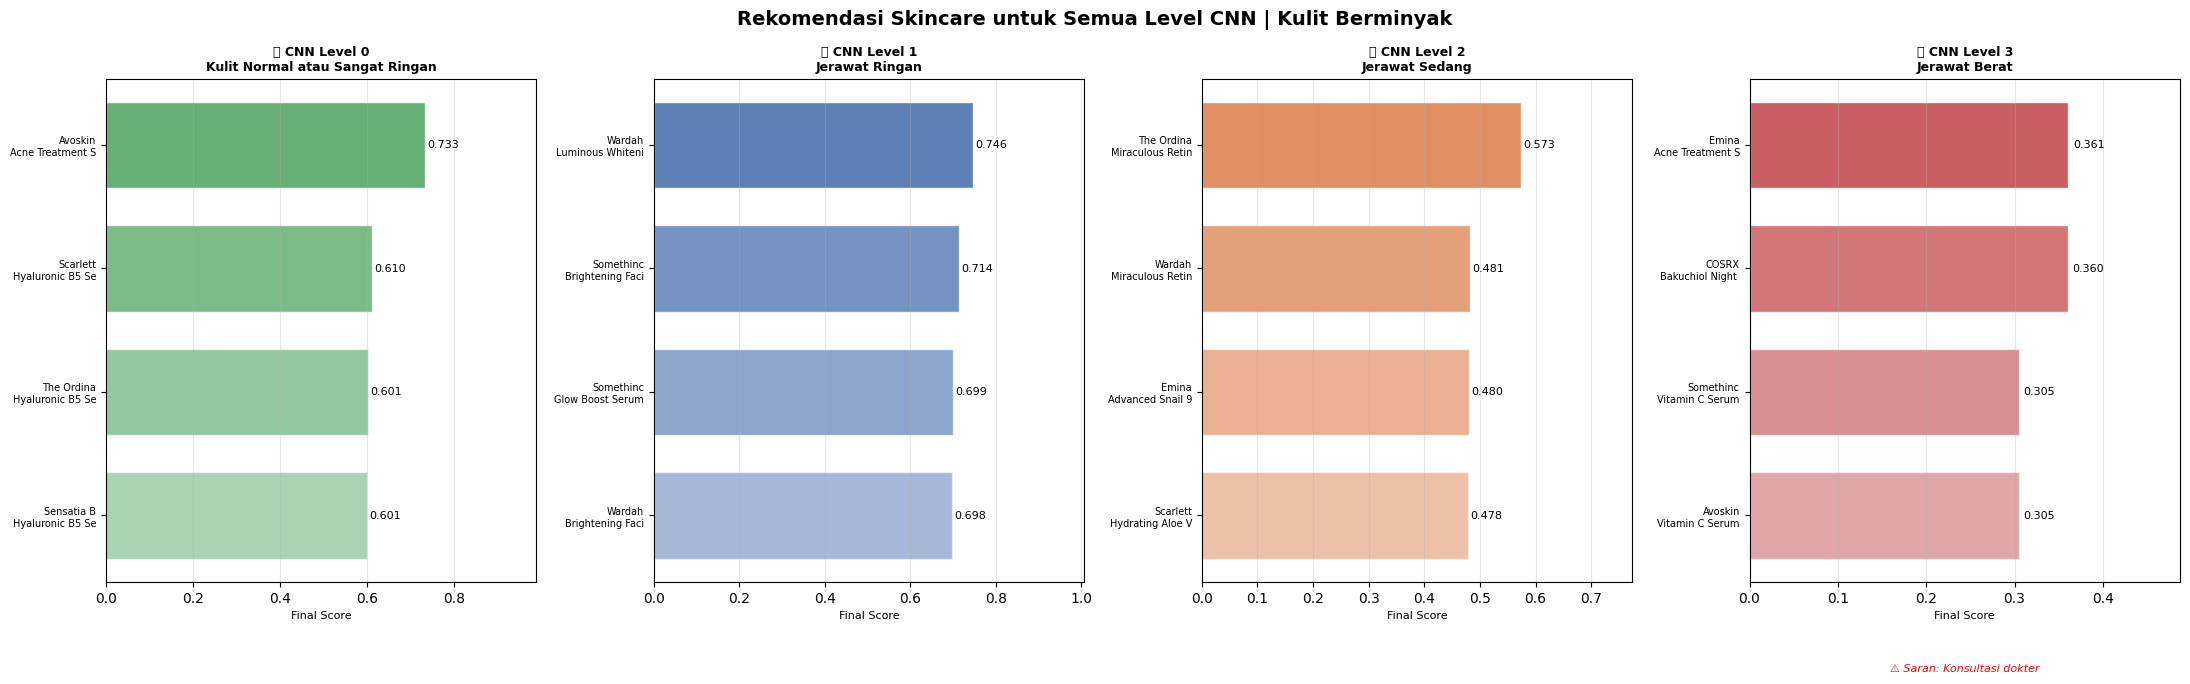

✅ Saved: rekomendasi_semua_level.png


In [122]:
# ── Bandingkan rekomendasi untuk semua 4 level sekaligus ──────
JENIS_KULIT_TEST = 'Berminyak'   # Ubah sesuai kebutuhan

fig, axes = plt.subplots(1, 4, figsize=(22, 7))
fig.suptitle(
    f'Rekomendasi Skincare untuk Semua Level CNN | Kulit {JENIS_KULIT_TEST}',
    fontsize=14, fontweight='bold'
)

for lvl in range(4):
    h = recommend_from_cnn_level(cnn_level=lvl, jenis_kulit=JENIS_KULIT_TEST, top_n=4)
    p = h['profile']
    r = h['rekomendasi']

    labels = [f"{row['Brand'][:10]}\n{row['Produk'][:16]}" for _, row in r.iterrows()]
    scores = r['final_score'].values
    bar_colors = [p['warna']] * len(scores)
    alphas = np.linspace(0.9, 0.5, len(scores))

    bars = axes[lvl].barh(labels[::-1], scores[::-1],
                           color=bar_colors, alpha=0.8, edgecolor='white', height=0.7)
    for bar, v, a in zip(bars, scores[::-1], alphas[::-1]):
        bar.set_alpha(a)
        axes[lvl].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                       f'{v:.3f}', va='center', fontsize=8)

    axes[lvl].set_title(
        f"{p['emoji']} CNN Level {lvl}\n{p['label'].split('—')[1].strip()}",
        fontsize=9, fontweight='bold'
    )
    axes[lvl].set_xlim([0, max(scores)*1.35 if len(scores) > 0 else 1])
    axes[lvl].set_xlabel('Final Score', fontsize=8)
    axes[lvl].tick_params(axis='y', labelsize=7)
    axes[lvl].grid(axis='x', alpha=0.3)

    if p['saran_dokter']:
        axes[lvl].text(0.5, -0.18, '⚠️ Saran: Konsultasi dokter',
                       transform=axes[lvl].transAxes, ha='center',
                       fontsize=8, color='red', style='italic')

plt.tight_layout()
plt.savefig('../output/rekomendasi_semua_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rekomendasi_semua_level.png')

---
## 7. Demo: Input Gambar Langsung (CNN → Skincare)

Pipeline lengkap dari gambar → CNN → rekomendasi skincare.

In [123]:
import tensorflow as tf
from tensorflow import keras

@tf.keras.utils.register_keras_serializable()
class FocalLoss(keras.losses.Loss):
    # Tambahkan reduction dan **kwargs di sini
    def __init__(self, gamma=2.0, name='focal_loss', reduction='sum_over_batch_size', **kwargs):
        # Teruskan reduction dan kwargs ke superclass Keras
        super().__init__(name=name, reduction=reduction, **kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=CONFIG['num_classes'])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = tf.pow(1.0 - pt, self.gamma)
        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma})
        return config

focal_loss = FocalLoss(gamma=2.0)
print('FocalLoss siap digunakan')

FocalLoss siap digunakan dengan perbaikan argument.


In [124]:
# Load model CNN
import tensorflow as tf
from PIL import Image

cnn_model = None
if os.path.exists(CONFIG['cnn_model_path']):
    cnn_model = tf.keras.models.load_model(CONFIG['cnn_model_path'], custom_objects={'FocalLoss': FocalLoss})
    print(f'✅ CNN model dimuat: {CONFIG["cnn_model_path"]}')
    print(f'   Input  : {cnn_model.input_shape}')
    print(f'   Output : {cnn_model.output_shape}')
else:
    print(f'⚠️  CNN model tidak ditemukan di: {CONFIG["cnn_model_path"]}')
    print('   → Jalankan cnn_crowd_level.ipynb terlebih dahulu')
    print('   → Atau gunakan fungsi predict_from_image_path() dengan level manual')

✅ CNN model dimuat: ../output/best_model.keras
   Input  : (None, 224, 224, 3)
   Output : (None, 4)


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_level_from_image(image_path: str) -> dict:
    if cnn_model is None:
        raise RuntimeError('CNN model belum dimuat. Load model terlebih dahulu.')

    img = Image.open(image_path).convert('RGB')
    img = img.resize(CONFIG['img_size'])
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0) 

    probs     = cnn_model.predict(arr, verbose=0)[0]
    pred_idx  = int(np.argmax(probs))

    return {
        'predicted_level': pred_idx,
        'confidence'     : float(probs[pred_idx]),
        'confidence_pct' : f'{probs[pred_idx]*100:.1f}%',
        'probabilities'  : {CNN_CLASS_NAMES[i]: f'{p*100:.1f}%' for i, p in enumerate(probs)},
    }


def full_pipeline(image_path: str, jenis_kulit: str, top_n: int = 5) -> dict:
    # Step 1: CNN prediksi
    cnn_result = predict_level_from_image(image_path)
    cnn_level  = cnn_result['predicted_level']

    # Step 2: Rekomendasi skincare
    rekom_result = recommend_from_cnn_level(
        cnn_level   = cnn_level,
        jenis_kulit = jenis_kulit,
        top_n       = top_n,
    )

    return {
        'image_path'      : image_path,
        'cnn_result'      : cnn_result,
        'skincare_result' : rekom_result,
    }


print('✅ full_pipeline() siap')
print('   Penggunaan:')
print('   hasil = full_pipeline("path/gambar.jpg", "Berminyak")')

✅ full_pipeline() siap
   Penggunaan:
   hasil = full_pipeline("path/gambar.jpg", "Berminyak")


In [126]:
# ══════════════════════════════════════════
#  Ganti path ini ke gambar wajah Anda
IMAGE_PATH  = r"C:\Files\Picture\089164900_1612949610-Penyebab-Jerawat-Kistik-dan-Cara-Mengatasinya-by-Nickel_Bell-Canva.jpg"  # contoh dari dataset NNEW
JENIS_KULIT = 'Berminyak'
# ══════════════════════════════════════════

if cnn_model is not None and os.path.exists(IMAGE_PATH):
    output = full_pipeline(IMAGE_PATH, JENIS_KULIT, top_n=5)

    c = output['cnn_result']
    s = output['skincare_result']
    p = s['profile']

    print('═'*55)
    print(f"  📸 GAMBAR  : {IMAGE_PATH}")
    print('═'*55)
    print(f"  CNN Level  : {c['predicted_level']} ({CNN_CLASS_NAMES[c['predicted_level']]})")
    print(f"  Confidence : {c['confidence_pct']}")
    print(f"  Semua prob : {c['probabilities']}")
    print('─'*55)
    print(f"  {p['emoji']} Kondisi   : {p['label']}")
    print(f"  📋 Masalah  : {s['masalah_dipakai']}")
    if p['saran_dokter']:
        print(f"  ⚠️  DISARANKAN KONSULTASI DOKTER KULIT")
    print('═'*55)

    display(s['rekomendasi'][['Brand','Produk','Jenis_Produk_Final',
                              'Tipe_Bahan_Aktif_Final','Level_Utama','final_score']]
            .style.background_gradient(subset=['final_score'], cmap='Greens')
            .format({'final_score': '{:.3f}'}))
else:
    print('⚠️  Demonstrasi tanpa gambar nyata:')
    print('   Simulasi CNN output = Level 2')
    hasil_sim = recommend_from_cnn_level(cnn_level=2, jenis_kulit='Berminyak', top_n=5)
    p = hasil_sim['profile']
    print(f"\n{p['emoji']} {p['label']}")
    print(f"   {p['deskripsi']}")
    display(hasil_sim['rekomendasi'][['Brand','Produk','Jenis_Produk_Final',
                                     'Tipe_Bahan_Aktif_Final','final_score']]
            .style.background_gradient(subset=['final_score'], cmap='Greens')
            .format({'final_score': '{:.3f}'}))

═══════════════════════════════════════════════════════
  📸 GAMBAR  : C:\Files\Picture\089164900_1612949610-Penyebab-Jerawat-Kistik-dan-Cara-Mengatasinya-by-Nickel_Bell-Canva.jpg
═══════════════════════════════════════════════════════
  CNN Level  : 0 (Level 0)
  Confidence : 76.7%
  Semua prob : {'Level 0': '76.7%', 'Level 1': '20.9%', 'Level 2': '1.2%', 'Level 3': '1.2%'}
───────────────────────────────────────────────────────
  🟢 Kondisi   : Level 0 — Kulit Normal atau Sangat Ringan
  📋 Masalah  : ['Dehidrasi', 'Kusam', 'Penuaan']
═══════════════════════════════════════════════════════


,Brand,Produk,Jenis_Produk_Final,Tipe_Bahan_Aktif_Final,Level_Utama,final_score
1,Avoskin,Acne Treatment Serum,Serum,Hyaluronic Acid,0,0.733
2,Scarlett,Hyaluronic B5 Serum,Serum,Hyaluronic Acid,0,0.610
3,The Ordinary,Hyaluronic B5 Serum,Serum,Hyaluronic Acid,0,0.601
4,Sensatia Botanicals,Hyaluronic B5 Serum,Serum,Hyaluronic Acid,0,0.601
5,Avoskin,Hyaluronic B5 Serum,Serum,Hyaluronic Acid,0,0.601


---
## 8. Simpan Model

In [127]:
os.makedirs('models', exist_ok=True)

model_bundle = {
    'df'                    : df,
    'tfidf'                 : tfidf,
    'tfidf_matrix'          : tfidf_matrix,
    'scaler'                : scaler,
    'cnn_to_skincare_profile': CNN_TO_SKINCARE_PROFILE,
    'config'                : CONFIG,
    'metadata': {
        'masalah_options'   : sorted(df['Masalah Kulit'].unique().tolist()),
        'kulit_options'     : sorted(df['Untuk Kulit'].unique().tolist()),
        'bahan_options'     : sorted(df['Tipe_Bahan_Aktif_Final'].unique().tolist()),
        'produk_options'    : sorted(df['Jenis_Produk_Final'].unique().tolist()),
        'total_produk'      : len(df),
        'cnn_levels'        : [0, 1, 2, 3],
        'python_version'    : '3.10.9',
        'model_type'        : 'skincare_cnn_integrated',
    }
}

out = CONFIG['output_model_path']
with open(out, 'wb') as f:
    pickle.dump(model_bundle, f)

size = os.path.getsize(out)/1024
print(f'✅ Model disimpan: {out} ({size:.1f} KB)')
print(f'\nIsi bundle:')
for k, v in model_bundle.items():
    if k == 'df':
        print(f'  {k:<28} : DataFrame ({len(df)} baris)')
    elif k == 'metadata':
        print(f'  {k:<28} : {v}')
    else:
        print(f'  {k:<28} : {type(v).__name__}')

✅ Model disimpan: ../output/skincare_cnn_integrated.pkl (109.8 KB)

Isi bundle:
  df                           : DataFrame (185 baris)
  tfidf                        : TfidfVectorizer
  tfidf_matrix                 : csr_matrix
  scaler                       : MinMaxScaler
  cnn_to_skincare_profile      : dict
  config                       : dict
  metadata                     : {'masalah_options': ['Bekas jerawat', 'Dehidrasi', 'Flek hitam', 'Iritasi', 'Jerawat', 'Kusam', 'Penuaan', 'Pori besar'], 'kulit_options': ['Berminyak', 'Kering', 'Kombinasi', 'Normal', 'Sensitif'], 'bahan_options': ['Bakuchiol', 'Ceramide', 'Hyaluronic Acid', 'Niacinamide', 'Retinol', 'Salicylic Acid', 'Tea Tree', 'Vitamin C'], 'produk_options': ['Cleanser', 'Cream', 'Essence', 'Gel', 'Gel Moisturizer', 'Moisturizer', 'Night Cream', 'Serum', 'Spot Treatment', 'Sunscreen', 'Toner'], 'total_produk': 185, 'cnn_levels': [0, 1, 2, 3], 'python_version': '3.10.9', 'model_type': 'skincare_cnn_integrated'}


In [128]:
# Verifikasi load ulang
with open(out, 'rb') as f:
    loaded = pickle.load(f)

print('✅ Verifikasi load berhasil')
print(f"   Total produk : {loaded['metadata']['total_produk']}")
print(f"   CNN levels   : {loaded['metadata']['cnn_levels']}")
print(f"   Kulit opsi   : {loaded['metadata']['kulit_options']}")
print(f"   Masalah opsi : {loaded['metadata']['masalah_options']}")

✅ Verifikasi load berhasil
   Total produk : 185
   CNN levels   : [0, 1, 2, 3]
   Kulit opsi   : ['Berminyak', 'Kering', 'Kombinasi', 'Normal', 'Sensitif']
   Masalah opsi : ['Bekas jerawat', 'Dehidrasi', 'Flek hitam', 'Iritasi', 'Jerawat', 'Kusam', 'Penuaan', 'Pori besar']
